# Purity Gain

## Decision trees

Gini impurity

In [178]:
iR = 1-(2/11)**2 - (5/11)**2 - (4/11)**2
iv1 = 1-(2/6)**2 - (4/6)**2
iv2 = 1-(4/5)**2 - (1/5)**2
purity_gain = iR - (6/11)* iv1 - (5/11) * iv2
print("Gini purity_gain is:", purity_gain)
436/1815

Gini purity_gain is: 0.24022038567493123


0.24022038567493112

Classification error

In [179]:
n_1 = 263
n_2 = 359
n_3 = 358
sum_num = n_1 + n_2 + n_3
print(sum_num)
iR = 1-(359/sum_num)
iv1 = 1 - (143/334)
iv2 = 1 - (304/646)
print(iR - (334/sum_num)*iv1 - (646/sum_num)*iv2)
# iv1 = 1 - (251/(223+251+197))
# iv2 = 1 - (max([n_1 - 223, n_2 - 251, n_3 - 197])/(sum_num - (223+251+197)))
# print(iR - ((223+251+197)/sum_num)* iv1 - ((sum_num - (223+251+197))/sum_num) * iv2)
# print(265/333)


980
0.08979591836734685


Entropy

In [180]:
import numpy as np
import math

iR = -(2/11)*np.log2(2/11) - (5/11)*np.log2(5/11) - (4/11)*np.log2(4/11)
iv1 = -(2/6)*np.log2(2/6) - (4/6)*np.log2(4/6)
iv2 = -(4/5)*np.log2(4/5) - (1/5)*np.log2(1/5)
purity_gain = iR - (6/11)* iv1 - (5/11) * iv2
print("Entropy purity gain is:", purity_gain)

Entropy purity gain is: 0.6658810774372464


In [181]:
iR = 1-32/56
iv1 = 1 - (23/31)
iv2 = 1 - (16/25)
print(iR - (31/56)* iv1 - (25/56) * iv2)

0.12500000000000003


## Regression trees

In [182]:
import numpy as np
r = np.array([23, 6, 17, 14, 13])
v1 = np.array([23])
v2 = np.array([6, 17, 14, 13])
num_obs = len(r)
iR = np.sum((r - r.mean())**2) / num_obs
iv1 = np.sum((v1 - v1.mean())**2) / len(v1)
iv2 = np.sum((v2 - v2.mean())**2) / len(v2)
print(iR, iv1, iv2)
iR - (len(v1)/num_obs)* iv1 - (len(v2)/num_obs) * iv2

30.639999999999997 0.0 16.25


17.639999999999997

# PCA

Don't forget to square it!!!

In [183]:
(43.4**2 +23.39**2 + 18.26**2) / (43.4**2 +23.39**2 + 18.26**2 + 9.34**2 + 2.14**2)

0.967850637640762

In [184]:
import numpy as np
input_string = """43.67 0.0 0.0 0.0 0.0 0.0
0.0 33.47 0.0 0.0 0.0 0.0
0.0 0.0 31.15 0.0 0.0 0.0
0.0 0.0 0.0 30.36 0.0 0.0
0.0 0.0 0.0 0.0 27.77 0.0
0.0 0.0 0.0 0.0 0.0 13.86"""

rows = [list(map(float, line.split())) for line in input_string.split('\n')]
matrix = np.array(rows)
singular_values = np.linalg.svd(matrix, compute_uv=False)

# Calculate total variance
total_variance = np.sum(singular_values**2)

# Calculate explained variance for each component
explained_variance = np.cumsum(singular_values**2)

# Print the explained variance for each component
for i, variance in enumerate(explained_variance):
    print(f"Explained Variance up to component {i+1}: {variance/total_variance:.4f}")

explained_variance_reverse = np.cumsum(singular_values[::-1]**2)[::1]

# Print the explained variance for each component (starting from the last)
for i, variance in enumerate(explained_variance_reverse):
    print(f"Explained Variance (Reverse) up to component {len(singular_values) - i}: {variance/total_variance:.4f}")


Explained Variance up to component 1: 0.3242
Explained Variance up to component 2: 0.5146
Explained Variance up to component 3: 0.6796
Explained Variance up to component 4: 0.8363
Explained Variance up to component 5: 0.9673
Explained Variance up to component 6: 1.0000
Explained Variance (Reverse) up to component 6: 0.0327
Explained Variance (Reverse) up to component 5: 0.1637
Explained Variance (Reverse) up to component 4: 0.3204
Explained Variance (Reverse) up to component 3: 0.4854
Explained Variance (Reverse) up to component 2: 0.6758
Explained Variance (Reverse) up to component 1: 1.0000


In [185]:
input_string = """0.38 -0.51 0.23 0.47 -0.55 0.11
                    0.41 0.41 -0.53 0.24 0.00 0.58
                    0.50 0.34 -0.13 0.15 -0.05 -0.77
                    0.29 0.48 0.78 -0.17 0.00 0.23
                    0.45 -0.42 0.09 0.03 0.78 0.04
                    0.39 -0.23 -0.20 -0.82 -0.30 0.04"""

rows = [list(map(float, line.split())) for line in input_string.split('\n')]
matrix = np.array(rows).T
x = np.array([-0.1, 0.2, 0.1, -0.3, 1, 0.5])
for i in range(len(matrix)):
    print(f"Projection on PC{i+1}:", np.dot(matrix[i], x))

Projection on PC1: 0.652
Projection on PC2: -0.5119999999999999
Projection on PC3: -0.386
Projection on PC4: -0.31299999999999994
Projection on PC5: 0.68
Projection on PC6: 0.01899999999999998


In [186]:
import numpy as np
V = np.array([[0.38, 0.41, 0.50, 0.29, 0.45, 0.39], [-0.51, 0.41, 0.34, 0.48, -0.42, -0.23]])
x = np.array([-0.1, 0.2, 0.1, -0.3, 1, 0.5])
for i in range(len(V)):
    print(f"Projection on PC{i+1}:", np.dot(V[i], x))

Projection on PC1: 0.652
Projection on PC2: -0.512


In [187]:
import numpy as np
x= np.array([[3.00, 2.00, 1.00], [4.00, 1.00, 2.00], [0.00, 1.00, 2.00]])
x_tilde = x - x.mean(axis=0)
v =np.array([[-0.99, -0.13, -0.00], [-0.09, 0.70, -0.71], [0.09, -0.70, -0.71]]) 
x_tilde @ v


array([[-7.80000000e-01,  8.46666667e-01, -2.14643118e-17],
       [-1.59000000e+00, -6.83333333e-01,  6.29126381e-18],
       [ 2.37000000e+00, -1.63333333e-01,  6.29126381e-18]])

In [188]:
import numpy as np
x = np.array([-0.5, 0.67, -0.67])
# mu = np.array([12.9, 58.2, 1.7, 1436.8, 4.1])
v1 = np.array([-0.99, -0.09, 0.09])
v2 = np.array([-0.13, 0.7, -0.7])
print(np.dot(x,v1))
print(np.dot(x,v2))

0.37439999999999996
1.0030000000000001


# Adaboost

In [189]:
import math
alpha = 0.5 * math.log(0.7/0.3)
alpha = math.log(math.sqrt(2))
# math.exp(alpha)/6, math.exp(-alpha)/6
1/(6*math.sqrt(2)), math.sqrt(2)/6

(0.1178511301977579, 0.23570226039551587)

Calculate normalized updated weights

In [190]:
import math
import numpy as np

num_obs = 7
init_weight = 1/num_obs
num_misclass = 5

e = num_misclass * init_weight
a = 0.5*math.log((1-e)/e)

weight_cor = init_weight*(math.exp(-a))
weight_err = init_weight*(math.exp(a))

weights = np.concatenate([np.full(num_misclass, weight_err), np.full(num_obs - num_misclass, weight_cor)])
normalized_weights = weights / np.sum(weights)
print(normalized_weights)

[0.1  0.1  0.1  0.1  0.1  0.25 0.25]


# KNN Density - Average Relative Density


In [191]:
d3 = 1/(0.5*(5.2+5.4))
d2 = 1/(0.5*(3.5+4))
d4= 1/(0.5*(3.3+4))
d3 / (0.5*(d2+d4))

0.6979857215706273

IF THERE ARE THREE NEIGHBORS THEY ARE PROBABLY ASKING FOR THE DENSITY ITSELF AND NOT THE ARD

In [192]:
p = 1/3
d5 = 1/(p*(24.2+37.7+38.5))
d4 = 1/(p*(24.2+33.4+37.2))
d6= 1/(p*(19.3+21.5+37.7))
d3= 1/(p*(19.3+35.5+38.5))
d5 / (p*(d4+d6+d3))

0.8786956989816073

In [193]:
import numpy as np
x1 = np.array([0.38, 0.41, 0.5, 0.29, 0.45, 0.39])
x2 = np.array([-0.1, 0.2, 0.1, -0.3, 1, 0.5])
np.dot(x1, x2)

0.652

# Jaccard  and Rand Index SMC cluster similarity USE COUNTING MATRIX

In [194]:
# import numpy as np

# def jaccard_smc_cluster_similarity(yb, z):
#     if len(yb) != len(z):
#         raise ValueError("Vectors must have the same length.")

#     unique_clusters = np.unique(z)

#     S = 0  # Number of pairs in the same cluster with the same class
#     D = 0  # Number of pairs in the same cluster with different classes
#     agree_count = 0  # Number of pairs with the same class

#     for cluster in unique_clusters:
#         indices_in_cluster = np.where(z == cluster)[0]
#         yb_in_cluster = yb[indices_in_cluster]

#         # Calculate S for the pairs in the same cluster with the same class
#         S += np.sum(np.bincount(yb_in_cluster) * (np.bincount(yb_in_cluster) - 1) // 2)

#         # Calculate D for the pairs in the same cluster with different classes
#         D += np.sum((np.bincount(yb_in_cluster) * (len(indices_in_cluster) - np.bincount(yb_in_cluster))))

#         # Calculate the number of pairs with the same class
#         agree_count += np.sum(np.bincount(yb_in_cluster) * (np.bincount(yb_in_cluster) - 1) // 2)

#     # Calculate Jaccard similarity
#     N = len(yb)
#     J = S / ((N * (N - 1)) / 2 - D) if ((N * (N - 1)) / 2 - D) > 0 else 0

#     # Calculate Simple Matching Coefficient (SMC)
#     SMC = agree_count / N

#     return J, SMC

# # Example usage:
# yb = np.array([0, 0, 1, 1, 1, 2, 2, 2, 2, 2])
# z = np.array([1, 1, 0, 1, 1, 1, 1, 0, 0, 3])

# jaccard_similarity, smc_similarity = jaccard_smc_cluster_similarity(yb, z)
# print("Jaccard Cluster Similarity:", jaccard_similarity)
# print("SMC Cluster Similarity:", smc_similarity)


# Rand Index and Jaccard Similarity for vectors


In [195]:
import numpy as np
from sklearn.metrics import jaccard_score, rand_score, adjusted_rand_score

# Given vectors
# x = np.full(1500, 0)
# y = np.full(1500, 1)
# print(x)
# x[0] = 1
# y[0] = 0
# y[1] = 0
x = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1])
y = np.array([0, 1, 1, 1, 1, 1, 0, 0, 0])

jaccard_similarity = jaccard_score(x, y)
print("Jaccard Index Similarity:", jaccard_similarity)

# rand_similarity = rand_score(x, y)
# print("Rand Index Similarity:", rand_similarity)

matching_positions = np.sum((x == 0) & (y == 0) | (x == 1) & (y == 1))
rand_similarity = matching_positions / len(x)
print("PROBABLY CORRECT Rand Index Similarity:", rand_similarity)

cosine_similarity = np.dot(x,y) / (np.linalg.norm(x) * np.linalg.norm(y))
print("Cosine Similarity:", cosine_similarity)

Jaccard Index Similarity: 0.0
PROBABLY CORRECT Rand Index Similarity: 0.3333333333333333
Cosine Similarity: 0.0


In [196]:
S = 114*113/2 + 119*118/2+60*59/2 + 32*31/2 + 8*7/2
N = 114+119+32+60+8
N = N*(N-1)/2
D = N - 146*145/2 -119*118/2 - 68*67/2 - 122*121/2 - 119*118/2 - 92*91/2 + S
print(N,S,D)
(S + D) / N 

55278.0 15756.0 32562.0


0.8740909584283079

# Cosine Similarity for vectors

In [197]:
import numpy as np
x = np.array([1,1,1,1,1,1,1,1,1,1,1,1,0,0,0])
y = np.array([1,0,0,0,1,1,0,0,0,1,0,0,1,1,1])
print(np.dot(x,y) / (np.linalg.norm(x) * np.linalg.norm(y)))

0.4364357804719848


In [198]:
import numpy as np
x = np.array([1, 0, 1, 0, 0, 1, 1, 0])
y = np.array([1, 0, 1, 0, 1, 0, 1, 0])
print(np.dot(x,y) / (np.linalg.norm(x) * np.linalg.norm(y)))

0.75


# p-distance

In [199]:
import numpy as np

x = np.array([1, 0.5])
y1 = np.array([0.301, 0.514])
y2 = np.array([0.34, 0.672])

# p = np.inf
p_distance1 = np.linalg.norm(x - y1, np.inf)
p_distance2 = np.linalg.norm(x - y2, np.inf)
print("inf-distance between x and point 1:", p_distance1)
print("inf-distance between x and point 2:", p_distance2)
print("p = inf class label is",  0 if p_distance1 < p_distance2 else 1)

ps = [1, 2, 4]
for p in ps:
    p_distance1 = np.linalg.norm(x - y1, p)
    p_distance2 = np.linalg.norm(x - y2, p)
    print(f"{p}-distance between x and point 1 = {p_distance1}")
    print(f"{p}-distance between x and point 2 = {p_distance2}")
    print(f"p = {p} class label is",  0 if p_distance1 < p_distance2 else 1)


inf-distance between x and point 1: 0.6990000000000001
inf-distance between x and point 2: 0.6599999999999999
p = inf class label is 1
1-distance between x and point 1 = 0.7130000000000001
1-distance between x and point 2 = 0.832
p = 1 class label is 0
2-distance between x and point 1 = 0.6991401862287706
2-distance between x and point 2 = 0.682043986851288
p = 2 class label is 1
4-distance between x and point 1 = 0.699000028120342
4-distance between x and point 2 = 0.6607597525404331
p = 4 class label is 1


# Mutual Information

In [200]:
# Create the matrix by 3x3 probably by assigning to position i,j the number of observations in cluster i of P and cluster j of Q
# Then calculate entropies of each cluster 
import math
sum_p1 = 0.3
sum_p2 = 0.5
sum_p3 = 0.2
h_p = -sum_p1 * math.log(sum_p1) - sum_p2 * math.log(sum_p2) - sum_p3 * math.log(sum_p3)
# print(h_p)
sum_q1 = 0.7
sum_q2 = 0.2
sum_q3 = 0.1
h_q = -sum_q1 * math.log(sum_q1) - sum_q2 * math.log(sum_q2) - sum_q3 * math.log(sum_q3)
# print(h_q)

# For the combined entropy just sum each individual component
pq1 = 0.2
pq2 = 0.1
pq3 = 0.3
pq4 = 0.2
pq5 = 0.2

h_pq = -pq1 * math.log(pq1) - pq2 * math.log(pq2) - pq3 * math.log(pq3) - pq4 * math.log(pq4) - pq5 * math.log(pq5)
# print(h_pq)
MI = h_p + h_q - h_pq
NMI = MI / (math.sqrt(h_p) * math.sqrt(h_q))
NMI

0.3019498874351785

In [201]:
import numpy as np
x = np.array([[2, 0, 1],
              [3, 2, 0],
              [2, 0, 0]])

N = np.sum(x)
x = x / N

sum_p = np.sum(x, axis=1)
sum_q = np.sum(x, axis=0)

h_p = np.sum(-sum_p * np.log(sum_p))
h_q = np.sum(-sum_q * np.log(sum_q))
h_pq = np.sum(-np.where(x != 0, x * np.log(np.where(x != 0, x, 1)), 0))

MI = h_p + h_q - h_pq
NMI = MI / (np.sqrt(h_p) * np.sqrt(h_q))

print("Mutual Information bewteen p and q:", MI)
print("Normalized Mutual Information bewteen p and q:", NMI)

Mutual Information bewteen p and q: 0.27435846855026513
Normalized Mutual Information bewteen p and q: 0.3019498874351785


# Logistic Regression Weights

In [202]:
import numpy as np
x = -1.5
w0 = -0.93
w1 = 1.72
1/(1+np.exp(-w0 - w1 * x))

0.02902903583634076

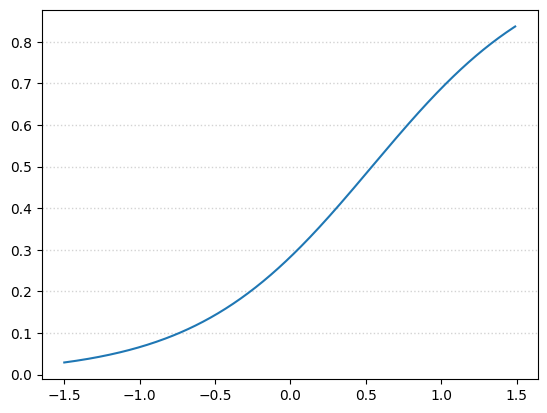

In [203]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(-1.5, 1.5, step=0.01)
w0 = -0.93
w1 = 1.72
res = []
for obs in x:
    res.append(1/(1+np.exp(-(w0 + w1 * obs))))

line_y_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
for y_value in line_y_values:
    plt.axhline(y=y_value, linestyle='dotted', color='lightgray', linewidth=1)
plt.plot(x, res)

# Linear Regression Model

In [204]:
x = np.array([1, 3, 4])
np.cos((np.pi * x)/2)

array([ 6.1232340e-17, -1.8369702e-16,  1.0000000e+00])

In [205]:
import numpy as np
#remember the 1 for the intercept
x = np.array([1, 2, 3, 4])
y = np.array([6, 2, 3, 4])

# Add a column of ones to x for the intercept
X = np.column_stack((np.ones_like(x), x))
# Calculate weights using the formula w = (X^TX)^-1 Xy
weights = np.linalg.inv(X.T @ X) @ X.T @ y

# Extract slope and intercept
w0, w1 = weights

print("Intercept (w0):", w0)
print("Slope (w1):", w1)

# Make a prediction for x = 5
x_new = 5
y_pred = w0 + w1 * x_new

print("Prediction for x = 5:", y_pred)


Intercept (w0): 5.0
Slope (w1): -0.49999999999999956
Prediction for x = 5: 2.500000000000002


Linear regression with features transformation. Apparently you don't need to insert the column of 1s in this case???

In [206]:
import numpy as np
#remember the 1 for the intercept
x = np.array([1, 2, 3, 4])
y = np.array([6, 2, 3, 4])

# Add a column of ones to x for the intercept
X_new = np.column_stack((np.cos(np.pi / 2 * x), np.sin(np.pi / 2 * x)))
# print(X_new)
# Calculate weights using the formula w = (X^TX)^-1 Xy
weights = np.linalg.inv(X_new.T @ X_new) @ X_new.T @ y

# Extract slope and intercept
w0, w1 = weights

print("Intercept (w0):", w0)
print("Slope (w1):", w1)

# Make a prediction for x = 5
x_new = 5
y_pred = w0 + w1 * x_new

print("Prediction for x = 5:", y_pred)

Intercept (w0): 1.0
Slope (w1): 1.4999999999999998
Prediction for x = 5: 8.5


# Ridge Regression

In [207]:
import numpy as np
y = np.array([6,7,7,9])
x = np.array([2,5,6,7])
ridge_lambda = 2
weight = 0.6

y_pred = (x - np.mean(x)) / np.std(x) * weight + np.sum(y)/len(y)
sum = 0
for i in range(len(y_pred)):
    sum += (y_pred[i] - y[i])**2
sum += ridge_lambda * (weight**2)
print("Error ridge with std ddof = 0:", sum)

y_pred = (x - np.mean(x)) / np.std(x, ddof=1) * weight + np.sum(y)/len(y)
sum = 0
for i in range(len(y_pred)):
    sum += (y_pred[i] - y[i])**2
sum += ridge_lambda * (weight**2)
print("Probably correct one, error ridge with std ddof = 1:", sum)

Error ridge with std ddof = 0: 2.420011135871271
Probably correct one, error ridge with std ddof = 1: 2.661555580955283


In [208]:
import numpy as np
y = np.array([6,2,3,4])
x = np.array([1,2,3,4])
w0 = 15/4
w1 = -np.sqrt(3/20)
(8 - np.linalg.norm(y - w0 *np.ones_like(x) - w1 * x)**2) / w1

8.555441711725964

# Gaussian Mixture Model (GMM)

Probability of a point belonging to a specific cluster

In [209]:
import math

x = 3.19
w1 = 0.19; mu1 = 3.177; sigma1_squared = 0.0062**2
w2 = 0.34; mu2 = 3.181; sigma2_squared = 0.0076**2
w3 = 0.48; mu3 = 3.184; sigma3_squared = 0.0075**2
# Probability density function for all clustes
p1_x = (w1 / math.sqrt(2 * math.pi * sigma1_squared)) * math.exp(-0.5 * (x - mu1)**2 / sigma1_squared)
p2_x = (w2 / math.sqrt(2 * math.pi * sigma2_squared)) * math.exp(-0.5 * (x - mu2)**2 / sigma2_squared)
p3_x = (w3 / math.sqrt(2 * math.pi * sigma3_squared)) * math.exp(-0.5 * (x - mu3)**2 / sigma3_squared)

print(f"The probability of our point to belong to cluster 1 is: {p1_x/(p1_x+p2_x+p3_x)}")
print(f"The probability of our point to belong to cluster 2 is: {p2_x/(p1_x+p2_x+p3_x)}")
print(f"The probability of our point to belong to cluster 3 is: {p3_x/(p1_x+p2_x+p3_x)}")

The probability of our point to belong to cluster 1 is: 0.047201959565534746
The probability of our point to belong to cluster 2 is: 0.30791129006046225
The probability of our point to belong to cluster 3 is: 0.644886750374003


Consider dimensions when dealing with distances

In [210]:
import math

dim = 10
w1 = 0.33; d1 = 2.11; sigma1_squared = 0.25
w2 = 0.33; d2 = 1.15; sigma2_squared = 0.25
w3 = 0.33; d3 = 1.09; sigma3_squared = 0.25

# Probability density function for all clusters
p1_x = (1 / math.sqrt((2 * math.pi * sigma1_squared)**dim)) * math.exp(-0.5 * (d1)**2 / sigma1_squared)
p2_x = (1 / math.sqrt((2 * math.pi * sigma2_squared)**dim)) * math.exp(-0.5 * (d2)**2 / sigma2_squared)
p3_x = (1 / math.sqrt((2 * math.pi * sigma3_squared)**dim)) * math.exp(-0.5 * (d3)**2 / sigma3_squared)

(p1_x + p2_x + p3_x)/3

0.005717945363896357

# Bayes Algorithm

In [211]:
pAfrica = 0.154
pNotAfrica = 1-pAfrica
pHighAfrica = 0.286
pHighNotAfrica = 0.688

pAfricaHigh = (pHighAfrica * pAfrica) / (pHighAfrica * pAfrica + pHighNotAfrica * pNotAfrica)
pAfricaHigh

0.07034748886745079

In [212]:
py1 = 0.17*0.268
py2 = 0.28*0.366
py3 = 0.33*0.365
print(py1/(py1+py2 + py3))

0.1696897463592685


In [213]:
low = 3285
med = 2190
high = 3285
sum = low + med + high
p_low = low/sum
p_med = med/sum
p_high = high/sum
pHighLow = (low - 1327)/low
pHighMed = (med - 1718)/med
pHighHigh = (high - 2344)/high
(p_high * pHighHigh) / (p_med * pHighMed + p_low * pHighLow + p_high * pHighHigh)

0.2791456541085731

# ANN

### ReLU


In [214]:
import numpy as np
# Remember to keep the 1 in the x input vector for the intercept
x = np.array([1, 1])
# Weights 
w1 = np.array([-1.8, -1.1])
w2 = np.array([-0.6, 3.8])
#Biases
b0 = -0.8
b1 = -0.1
b2 = 2.1

def relu(z):
    return np.maximum(z, 0)

b0 + b1 * relu(np.dot(x,w1)) + b2 * relu(np.dot(x,w2))

5.92

In [215]:
import numpy as np
# Remember to keep the 1 in the x input vector for the intercept
x = np.array([1, 1])
# Weights 
w1 = np.array([-1.8, -1.1])
w2 = np.array([-0.6, 3.8])
#Biases
b0 = -0.8
b1 = -0.1
b2 = 2.1

def relu(z):
    return np.maximum(z, 0)

b0 + b1 * relu(np.dot(x,w1)) + b2 * relu(np.dot(x,w2))

5.92

### Sigmoid

In [216]:
import numpy as np
# Remember to keep the 1 in the x input vector for the intercept
x = np.array([1, 3, 3])
# Weights 
w1 = np.array([-1.2, -1.3, 0.6])
w2 = np.array([-1.0, 0, 0.9])
#Biases
b0 = 2.2
b1 = -0.3
b2 = 0.5

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# print(sigmoid(np.dot(x,w1)), sigmoid(np.dot(x,w2)))
print(b0 + b1 * sigmoid(np.dot(x,w1)) + b2 * sigmoid(np.dot(x,w2)))
# print(sigmoid(b0 + b1 * sigmoid(np.dot(x,w1)) + b2 * sigmoid(np.dot(x,w2))))

2.612096010676442


# Naive Bayes

In [217]:
from fractions import Fraction
p1 = 2/3 * 2/3 * 2/3 * 3/10
p2 = 1 * 1/2 * 1 * 2/10
p3 = 4/5 * 3/5 * 1/5 * 5/10
p_NB = p1 / (p1 + p2 + p3)
print(p_NB)
print(Fraction(p_NB).limit_denominator())

0.3752345215759849
200/533


In [218]:
200/533

0.37523452157598497

# Distance measures

In [219]:
x1 = 0.301
x2 = 0.34
y1 = 0.514
y2 = 0.672
(x1-x2)

-0.039000000000000035

# Multinomial regression model and Softmax|

Multinomial regression model with 3 classes

In [220]:
import numpy as np
# Don't forget the 1 for the intercept
b = np.array([1, 2.5, 1])
w1 = np.array([0.51, 1.65, 0.01])
w2 = np.array([0.1, 3.8, 0.04])

def softmax(y1, y2):
    res1 = np.exp(y1)/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    res2 = np.exp(y2)/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    res3 = 1/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    print("Probability of belonging to class 1:", res1)
    print("Probability of belonging to class 2:", res2)
    print("Probability of belonging to class 3:", res3)
    return np.argmax(np.array([res1, res2, res3])) + 1


print(softmax(np.dot(b, w1), np.dot(b,w2)))

Probability of belonging to class 1: 0.006725738608569441
Probability of belonging to class 2: 0.9932096302067883
Probability of belonging to class 3: 6.463118464223333e-05
2


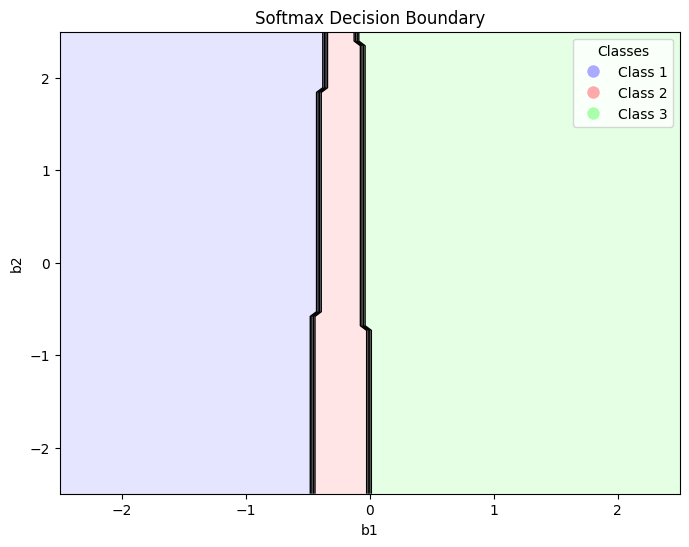

In [221]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Don't forget the 1 for the intercept
b = np.array([1, 2.5, 1])
w1 = np.array([-0.9, -4.39, -0.0])
w2 = np.array([-0.09, -2.45, -0.04])

def softmax(y1, y2):
    res1 = np.exp(y1)/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    res2 = np.exp(y2)/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    res3 = 1/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    # print("Probability of belonging to class 1:", res1)
    # print("Probability of belonging to class 2:", res2)
    # print("Probability of belonging to class 3:", res3)
    return np.argmax(np.array([res1, res2, res3])) + 1

# Create a 2D grid of points
b1_values = np.linspace(-2.5, 2.5, 100)
b2_values = np.linspace(-2.5, 2.5, 100)
B1, B2 = np.meshgrid(b1_values, b2_values)
B0 = np.ones_like(B1)

# Flatten the grids for prediction
B1_flat = B1.flatten()
B2_flat = B2.flatten()
B0_flat = B0.flatten()

# Predict the class for each point in the grid
predictions = np.array([softmax(np.dot(np.array([b0, b1, b2]), w1), np.dot(np.array([b0, b1, b2]), w2))
                        for b0, b1, b2 in zip(B0_flat, B1_flat, B2_flat)])

# Reshape the predictions to the shape of the grid
predictions = predictions.reshape(B1.shape)

# Plot the decision regions
plt.figure(figsize=(8, 6))
cmap_background = ListedColormap(['#AAAAFF', '#FFAAAA', '#AAFFAA'])
contour = plt.contourf(B1, B2, predictions, cmap=cmap_background, alpha=0.3)

# Plot the decision boundary
plt.contour(B1, B2, predictions, colors='black', linewidths=1)

# Set labels and show the plot
plt.xlabel('b1')
plt.ylabel('b2')
plt.title('Softmax Decision Boundary')

# Create a legend
legend_labels = {1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
           for color, label in zip(cmap_background.colors, legend_labels.values())]
plt.legend(handles=handles, title='Classes', loc='upper right')

plt.show()


In [222]:
import numpy as np
def softmax(y1, y2):
    res1 = np.exp(y1)/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    res2 = np.exp(y2)/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    res3 = 1/(1 + np.sum([np.exp(y1), np.exp(y2)]))
    print("Probability of belonging to class 1:", res1)
    print("Probability of belonging to class 2:", res2)
    print("Probability of belonging to class 3:", res3)
    return np.argmax(np.array([res1, res2, res3])) + 1


print(softmax(0.03, -1.89))

Probability of belonging to class 1: 0.4723548433688405
Probability of belonging to class 2: 0.06925050863386308
Probability of belonging to class 3: 0.4583946479972964
1


# Kernel Density Estimator

KDE when we perform LOO on all observations of x. In this case we need to loop over a couple of times. 

In [223]:
from scipy.stats import norm
import numpy as np

x = np.array([3.918, -6.35, -2.677, -3.003])
std_dev = 2

res = []
for i in x:
    sum = 0
    for j in x:
        if(j==i):
            continue
        sum += norm.pdf(i, j, std_dev)
    sum /= (len(x) - 1)
    res.append(sum)

sum = 0
for i in res:
    # Using the log likelihood
    sum += (-np.log(i))
sum /= len(res)

print(res)
print(sum)

[0.0004564791507104215, 0.028704952488396496, 0.07821583958100119, 0.0821712002583539]
4.072471660359569


KDE when we perform CV on only one of the observations present in x

In [224]:
x = np.array([4.5, -0.5])
y = np.array([1.2])
std_dev = 2
p_x = np.sum(norm.pdf(x, y[0], std_dev))/len(x)   # we divide by len(x) because we also need to account for the test observation which in this case is stored outside
-np.log(p_x)

2.3532212068063405

When the bandwidth is small compared to the distance bewteen components each density function is influenced primarily only by itself. So we can use the Gaussian formula which states p(x) = 1/(N * sqrt(2 * pi) * band_width) and find N given the value of p(x) obtained from the graph

In [225]:
import numpy as np
N = (1 / (np.sqrt(2 * np.pi) * 0.168 * 0.26))
N

9.133293965234266

In [226]:
(np.exp(-24.2/(2*20**2)) + np.exp(-39.4/(2*20**2)))

1.922146066658278

# Correlation

In [227]:
import numpy as np

cov = -29
var_x1 = 12
var_x2 = 6104
corr = cov/(np.sqrt(var_x1) * np.sqrt(var_x2))
corr

-0.10715195825624312

In [228]:
(12-20/3)**2

28.444444444444443

# McNemar test

In [229]:
import numpy as np
n11 = np.array([86,65,79])
n12 = np.array([8,15,5])
n21 = np.array([7,11,17])
n22 = np.array([10,20,10])
print((np.sum(n12) - np.sum(n21))/ (np.sum(n11) + np.sum(n12) + np.sum(n21) + np.sum(n22)))
s = np.sum(n21) + np.sum(n21)
s

-0.021021021021021023


70

# Jeffrey's interval

In [230]:
import numpy as np
n11 = np.array([134,141,131,132])
n12 = np.array([40,31,23,30])
n21 = np.array([24,26,25,25])
n22 = np.array([47,48,66,58])
total_n = (np.sum(n11) + np.sum(n12) + np.sum(n21) + np.sum(n22))
m = np.sum(n11) + np.sum(n21)
a = m + 0.5
b = total_n - m + 0.5
a,b

(638.5, 343.5)

# K-means

In [231]:
import numpy as np
from sklearn.cluster import KMeans
x = np.array([1.0, 1.2, 1.8, 2.3, 2.6, 3.4, 4.0, 4.1, 4.2, 4.6]).reshape(-1, 1)
K = 3
initial_centers = np.array([1.8, 3.3, 3.6]).reshape(-1, 1)
kmeans = KMeans(n_clusters=K, init=initial_centers, n_init=1, algorithm='lloyd')
kmeans.fit(x)
final_centers = kmeans.cluster_centers_
cluster_assignments = kmeans.labels_
print("Final cluster centers:", final_centers.flatten())
print("Cluster assignments:", cluster_assignments)
for cluster_num in range(K):
    cluster_values = x[cluster_assignments == cluster_num].flatten()
    print(f"Cluster {cluster_num + 1} values:", cluster_values)

Final cluster centers: [1.33333333 2.76666667 4.225     ]
Cluster assignments: [0 0 0 1 1 1 2 2 2 2]
Cluster 1 values: [1.  1.2 1.8]
Cluster 2 values: [2.3 2.6 3.4]
Cluster 3 values: [4.  4.1 4.2 4.6]


# Fmeasure with Precision-Recall

In [232]:
prec = 34/41
rec = 34/45
F1 = (2 * prec * rec) / (prec + rec)
F1

0.7906976744186047

# AUC and ROC

In [233]:
import numpy as np
# Follow the confusion matrix format
# [tp, fn]
# [fp, tn]
conf_matrix = np.array([[2, 1], 
                        [0, 8]])
tpr = conf_matrix[0][0] / (conf_matrix[0][0] + conf_matrix[0][1])
fpr = conf_matrix[1][0] / (conf_matrix[1][0] + conf_matrix[1][1])
print(fpr, tpr)
labels = np.array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1])

0.0 0.6666666666666666


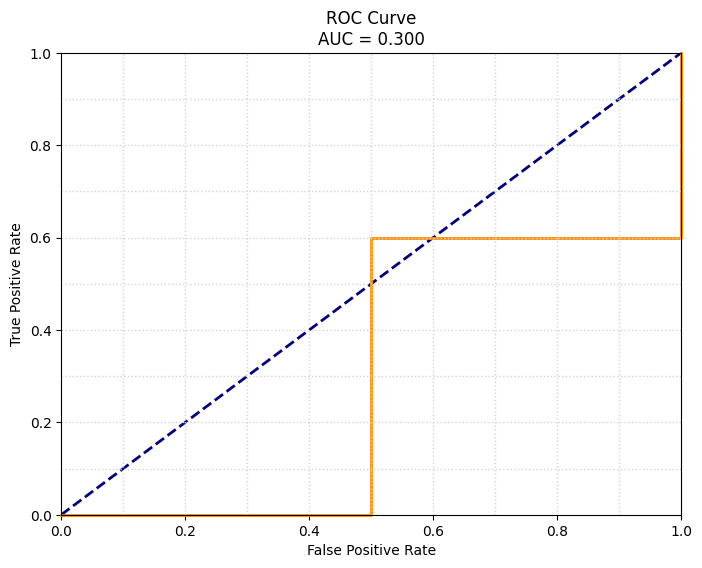

In [234]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, auc

def compute_roc_curve(labels):
    tpr_values = []
    fpr_values = []

    for i in range(len(labels) + 1):
        if(i == len(labels)):
            pred = np.zeros(len(labels))
        else:
            pred = np.concatenate([np.zeros(i), np.ones(len(labels) - i)])

        conf_matrix = confusion_matrix(labels, pred)
        true_negatives, false_positives, false_negatives, true_positives = conf_matrix.ravel()

        tpr = true_positives / (true_positives + false_negatives)
        fpr = false_positives / (false_positives + true_negatives)

        tpr_values.append(tpr)
        fpr_values.append(fpr)

    return np.array(fpr_values), np.array(tpr_values)

def plot_roc_curve(fpr, tpr, auc_score, title="ROC Curve"):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, zorder=2, clip_on=False)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', zorder=1)
    line_y_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    for y_value in line_y_values:
        plt.axhline(y=y_value, linestyle='dotted', color='lightgray', linewidth=1)
        plt.axvline(x=y_value, linestyle='dotted', color='lightgray', linewidth=1)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"{title}\nAUC = {auc_score:.3f}")
    plt.show()

labels = np.array([1, 1, 0, 1, 1, 1, 0])
fpr, tpr = compute_roc_curve(labels)
auc_score = auc(fpr, tpr)

plot_roc_curve(fpr, tpr, auc_score, title="ROC Curve")


# Average linkage

In [235]:
(1025 + 925 + 1375 + 1100 + 1000 + 1450) / 6

1145.8333333333333

# Dendrogram, Average relative density

As a method use:
- 'single' for minimum linkage
- 'complete' for maximum linkage
- 'average' for average linkage

In [236]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

input_string = """0.0 2.39 1.73 0.96 3.46 4.07 4.27 5.11
2.39 0.0 1.15 1.76 2.66 5.36 3.54 4.79
1.73 1.15 0.0 1.52 3.01 4.66 3.77 4.90
0.96 1.76 1.52 0.0 2.84 4.25 3.80 4.74
3.46 2.66 3.01 2.84 0.0 4.88 1.41 2.96
4.07 5.36 4.66 4.25 4.88 0.0 5.47 5.16
4.27 3.54 3.77 3.80 1.41 5.47 0.0 2.88
5.11 4.79 4.90 4.74 2.96 5.16 2.88 0.0
"""

rows = [list(map(float, line.split())) for line in input_string.split('\n')]

matrix = np.array(rows)
print(matrix)
condensed_distance = squareform(matrix)
linkage_matrix = hierarchy.linkage(condensed_distance , method='complete')
plt.figure(figsize=(10, 6))
dendrogram = hierarchy.dendrogram(linkage_matrix, labels=[f'O{i+1}' for i in range(len(rows))])
line_y_values = [1, 2, 3, 4, 5, 6, 7, 8]
for y_value in line_y_values:
    plt.axhline(y=y_value, linestyle='dotted', color='lightgray', linewidth=1)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Distance')
plt.show()


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (9,) + inhomogeneous part.

In [ ]:
def calculate_density(xi, K, distance_matrix):
    nearest_neighbors_indices = np.argsort(matrix[xi])[1:K+1]
    density = 1 / (np.sum(distance_matrix[xi, nearest_neighbors_indices]) / K)
    return density

def calculate_average_relative_density(xi, K, density_values, distance_matrix):
    print("Primary observation density:", calculate_density(xi, K, distance_matrix))
    ard = calculate_density(xi, K, distance_matrix) / (np.sum(density_values) / K)
    return ard

observation_index = 5  # Assuming 1-indexed

# Set the number of nearest neighbors (K)
K = 2

# Find the K nearest neighbors
nearest_neighbors_indices = np.argsort(matrix[observation_index - 1])[1:K+1] + 1
print("Nearest neighbors: ",nearest_neighbors_indices)

# Calculate the density for each nearest neighbor
density_values = [calculate_density(neighbor - 1, K, matrix) for neighbor in nearest_neighbors_indices]
print("Nearest neighbors densities", density_values)

# Calculate the average relative density
average_relative_density = calculate_average_relative_density(observation_index - 1, K, density_values, matrix)

print("Average Relative Density:", average_relative_density)
print("BE SURE TO CHECK IF YOU NEED ARD OR SIMPLE DENSITY")

Nearest neighbors:  [4 6]
Nearest neighbors densities [0.6451612903225806, 0.6060606060606061]
Primary observation density: 0.5128205128205129
Average Relative Density: 0.8197115384615385
BE SURE TO CHECK IF YOU NEED ARD OR SIMPLE DENSITY


In [ ]:
import numpy as np

distance_matrix = matrix

class_labels = [[1, 2], [3, 4, 5], [6, 7, 8, 9, 10]]
k_neighbors = 3

class_mapping = {obs: class_idx + 1 for class_idx, class_list in enumerate(class_labels) for obs in class_list}

labels_flat = [class_mapping[obs] for obs in range(1, 11)]

correct_predictions = 0

for i in range(len(distance_matrix)):
    distances = distance_matrix[i]
    labels = labels_flat.copy()

    sorted_indices = np.argsort(distances)
    sorted_labels = [labels[j] for j in sorted_indices]

    sorted_labels = sorted_labels[1:k_neighbors + 1]

    # Break ties if there is a tie
    if len(set(sorted_labels)) < k_neighbors:
        unique_labels, counts = np.unique(sorted_labels, return_counts=True)
        majority_class = unique_labels[np.argmax(counts)]
        # Check if the majority class matches the true class
        if majority_class == labels_flat[i]:
            correct_predictions += 1
    else:
        # Use the majority class if there is no tie
        # majority_class = max(set(sorted_labels), key=sorted_labels.count)
        majority_class = sorted_labels[0]
        # Check if the majority class matches the true class
        if majority_class == labels_flat[i]:
            correct_predictions += 1

error_rate = 1 - (correct_predictions / len(distance_matrix))
print(f"Error Rate: {error_rate:.2%}")


Error Rate: 60.00%


In [ ]:
from collections import Counter

dist_matrix = matrix

class_labels = [[1,2],[3,4,5],[6,7,8,9,10]]

K = 3
error_count = 0

for i in range(10):
    distances = dist_matrix[i]
    # print(distances)
    neighbors = np.argsort(distances)[1:K+1] + 1
    # print(neighbors)
    # break
    neighbor_classes = [c for c, observations in enumerate(class_labels, 1) for j in neighbors if j+1 in observations]
    majority_class = Counter(neighbor_classes).most_common(1)[0][0]
    true_class = [c for c, observations in enumerate(class_labels, 1) if i+1 in observations][0]
    if majority_class != true_class:
        error_count += 1

error_rate = error_count / 10

print(f"The error rate of the leave-one-out KNN classifier is {error_rate}")


The error rate of the leave-one-out KNN classifier is 0.7


# Gaussian distribution

In [ ]:
from scipy.stats import norm
import numpy as np

std_dev = np.sqrt(400)
mu = 13.95
x = 14
print(norm.pdf(x, mu, std_dev))
(1 / np.sqrt(2 * np.pi * std_dev**2)) * np.exp(-0.5 * (x - mu)**2 / std_dev**2)

0.01994705168543772


0.019947051685437717

In [ ]:
(0.0199**2 *2/11)/0.00010141

0.7100070819625104

# Compute the variance/standard deviation for inverse student-t distribution

In [ ]:
import numpy as np
x = np.array([1, 3, 3, 1, 2, 3, 1])
def calculate_sigma(x):
    n = len(x)
    z_hat = np.mean(x)
    sigma = np.sum((x - z_hat)**2) / (n * (n - 1))
    return np.sqrt(sigma)

result_sigma = calculate_sigma(x)

print("Resulting Sigma:", result_sigma)
1/np.sqrt(7)

Resulting Sigma: 0.3779644730092272


0.3779644730092272

# Logarithm

In [ ]:
import numpy as np
K = 9
n_out = 800
m_out = 200
n_in = n_out - (n_out / K)
m_in = n_out / K
K * (3 * (n_in * np.log2(n_in) + m_in)) + n_out * np.log2(n_out) + m_out

192214.56376780212

# Decison tree boundaries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vector =  np.asarray([1,2])
print(np.linalg.norm(vector))
x1=0
x2=0
x=np.asarray([x1,x2])
l1_norm = np.linalg.norm(vector, ord=1)
A = np.linalg.norm(x - np.asarray([0,0.5]),ord =np.inf) < 0.5
B=x1<0.75
C =np.linalg.norm(x -np.asarray([0.75,0.5]),ord =2) < 0.25
D =np.linalg.norm(x -np.asarray([0.75,0.5]),ord =1) < 0.25
print(f"Branch A {A} Branch B {B} Branch C {C} Branch D {D}")


start = 0
end = 1.001
precision = 0.001

# coordinaes
x = np.arange(start, end, precision)
y = np.arange(start, end, precision)

#meshgrid
X, Y = np.meshgrid(x, y)
colors = np.zeros((X.shape[0], X.shape[1]))

#X[i, j] ,Y[i, j] way to acces points
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        point = np.asarray([X[i, j] ,Y[i, j] ])
        #A
        if(np.linalg.norm(point- np.asarray([0,0.5]),ord =np.inf) < 0.5):
            # if X[i, j] > 0.5 :
                colors[i, j] = 1
        else:
            #B
            if(X[i, j]<0.75):
                #C
                if(np.linalg.norm(point -np.asarray([0.75,0.5]),ord =2) < 0.25):
                    colors[i, j] = 1
            else:
                #D
                if(np.linalg.norm(point -np.asarray([0.75,0.5]),ord =1) < 0.25):
                    colors[i, j] = 1

# Plot the coordinates with colors
plt.figure(figsize=(6, 6))
plt.scatter(X, Y, c=colors, cmap='gray', s=1)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.show()

# Confusion matrix

In [ ]:
import numpy as np
from fractions import Fraction
conf_matrix = np.array([[14, 18],
                       [10, 14]])

TP = conf_matrix[0][0]
TN = conf_matrix[1][1]
FP = conf_matrix[1][0]
FN = conf_matrix[0][1]

precision = TP / (TP + FP)
recall = TP / (TP + FN)
false_positive_rate = FP / (FP + TN)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Precision:{precision}, {Fraction(precision).limit_denominator()}")
print(f"Recall (True Positive Rate): {recall}, {Fraction(recall).limit_denominator()}")
print(f"False Positive Rate: {false_positive_rate}, {Fraction(false_positive_rate).limit_denominator()}")
print(f"Accuracy: {accuracy}, {Fraction(accuracy).limit_denominator()}")


Precision:0.5833333333333334, 7/12
Recall (True Positive Rate): 0.4375, 7/16
False Positive Rate: 0.4166666666666667, 5/12
Accuracy: 0.5, 1/2


# Counting matrix for cluster similarity Rand (SMC), Jaccard

In [ ]:
import numpy as np
from fractions import Fraction

x = np.array([[2, 0, 0],
              [2, 1, 0],
              [2, 2, 1]])

N = np.sum(x)

sum_p = np.sum(x, axis=1)
sum_q = np.sum(x, axis=0)
N1 = N*(N-1)/2
S = np.sum(x * (x - 1) / 2)
D = N1 - np.sum(sum_p * (sum_p - 1) / 2) - np.sum(sum_q * (sum_q - 1) / 2) + S
print(f"Rand index: {(S + D)/(N1)}, {Fraction((S + D)/(N1)).limit_denominator()}")
print(f"Jaccard similarity: {(S)/(N1 - D)}, {Fraction((S)/(N1-D)).limit_denominator()}")

Rand index: 0.4666666666666667, 7/15
Jaccard similarity: 0.14285714285714285, 1/7


# Apriori algorithm

In [ ]:
from itertools import combinations
import numpy as np

input_string = """0 0 1 0
0 0 0 1"""

rows = [list(map(float, line.split())) for line in input_string.split('\n')]
matrix = np.array(rows)
num_items = matrix.shape[1]
num_1s = np.sum(matrix[0])
# print(num_1s)
C2_prime_idx = list(combinations(range(num_items), int(num_1s + 1)))
C2_prime = np.zeros((len(C2_prime_idx), num_items))
# Set the elements at the indices specified in C2_prime_idx to 1
for i, indices in enumerate(C2_prime_idx):
    C2_prime[i, list(indices)] = 1

print("C2_prime:")
print(C2_prime)
rows_to_keep = []
matrix_pairs = [tuple(np.where(row == 1)[0]) for row in matrix]
for row in C2_prime:
    # Generate all pairs of indices where the row elements are 1
    pairs = list(combinations(np.where(row == 1)[0], int(num_1s)))
    # print(np.where(row == 1)[0], pairs)
    # break
    
    # Check if all pairs are present in L2
    if all(pair in matrix_pairs for pair in pairs):
        # If all pairs are present in L2, add the row to rows_to_keep
        rows_to_keep.append(row)

# Convert rows_to_keep to a numpy array
resulting_matrix = np.array(rows_to_keep)

print("Resulting matrix:")
print(resulting_matrix)


1.0
C2_prime:
[[1. 1. 0. 0.]
 [1. 0. 1. 0.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 1. 1.]]
Resulting matrix:
[[0. 0. 1. 1.]]


In [ ]:
1/(1499)

0.00066711140760507